# Hands-On 1: Environment and dataset exploration

Worked responses accompany the same experiments.

## Environment setup

Create the course environment once, then select its kernel in Jupyter:

```bash
conda env create -f environment.yml
conda activate ml-course
python -m pip install -e .
python -m ipykernel install --user --name ml-course --display-name "ML Course"
jupyter lab
```

Run these commands from the extracted course folder. A lightweight alternative is a virtual environment with `python -m pip install -r requirements.txt` followed by `python -m pip install -e .`.

In Colab, make the extracted course folder available in the runtime or mounted Drive. Set `MLCOURSE_ROOT` to that folder if it is outside the current location. Run the first two collapsed cells; the shared setup installs only missing packages there.

The experiments below separate the environment check from dataset exploration.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from mlcourse.labs import histogram_grid
import importlib.metadata

## 1. Check the environment

Run the environment check. Confirm which Python executable the notebook kernel uses.

**Prediction:** Why might two notebooks on the same computer see different installed packages?

Different kernels can run Python from different environments, each with its own packages.

In [3]:
print(f'Python executable: {sys.executable}')
for package in ['numpy', 'pandas', 'matplotlib', 'scikit-learn']:
    print(f'{package}: {importlib.metadata.version(package)}')

Python executable: /opt/anaconda3/envs/ac1-ml/bin/python
numpy: 2.5.3
pandas: 3.0.5
matplotlib: 3.11.2
scikit-learn: 1.9.1


**Observation:** Confirm that the executable belongs to your chosen environment.

The printed executable identifies the active Python installation. The package versions identify what this kernel can import.

**Explanation:** What is the relationship between a kernel and an environment?

A notebook sends code to its kernel process. Choosing a kernel selects the interpreter and package environment used to execute that code.

## 2. Inspect a dataframe

Read the reservations dataset. Inspect `head()`, `dtypes` and `describe()`.

**Prediction:** Will every numeric-looking column represent a continuous quantity?

No. Numeric values can represent counts, ordered values or category codes.

In [4]:
data = load_course_data('hotel')
display(data.head())
print(f'Rows: {data.shape[0]}; columns: {data.shape[1]}')
display(data.dtypes.to_frame('dtype'))
display(data.describe())

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,...,0,0,65.000,0,Not_Canceled
1,INN00002,2,0,2,3,...,0,0,106.680,1,Not_Canceled
2,INN00003,1,0,2,1,...,0,0,60.000,0,Canceled
3,INN00004,2,0,0,2,...,0,0,100.000,0,Canceled
4,INN00005,2,0,1,1,...,0,0,94.500,0,Canceled


Rows: 36275; columns: 19


,dtype
Booking_ID,str
no_of_adults,int64
no_of_children,int64
no_of_weekend_nights,int64
no_of_week_nights,int64
...,...
no_of_previous_cancellations,int64
no_of_previous_bookings_not_canceled,int64
avg_price_per_room,float64
no_of_special_requests,int64


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,...,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000,36275.000,36275.000,36275.000,36275.000,...,36275.000,36275.000,36275.000,36275.000,36275.000
mean,1.845,0.105,0.811,2.204,0.031,...,0.026,0.023,0.153,103.424,0.620
std,0.519,0.403,0.871,1.411,0.173,...,0.158,0.368,1.754,35.089,0.786
min,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000
25%,2.000,0.000,0.000,1.000,0.000,...,0.000,0.000,0.000,80.300,0.000
50%,2.000,0.000,1.000,2.000,0.000,...,0.000,0.000,0.000,99.450,0.000
75%,2.000,0.000,2.000,3.000,0.000,...,0.000,0.000,0.000,120.000,1.000
max,4.000,10.000,7.000,17.000,1.000,...,1.000,13.000,58.000,540.000,5.000


**Observation:** Identify one count, one measurement and one category.

`no_of_children` is a count, `avg_price_per_room` is a measurement and `booking_status` is a category. The dataframe has 36,275 rows and 19 columns.

**Explanation:** Why distinguish storage type from the meaning of a feature?

Storage type controls available operations but does not establish a meaningful distance. Treating category codes as continuous measurements can impose an unintended ordering.

## 3. Select and filter observations

Inspect selected columns, compute a mean and filter rows using two conditions.

**Prediction:** How should combining conditions with `&` change the selected rows?

Both conditions must hold, so the intersection cannot contain more rows than either condition alone.

In [5]:
display(data[['room_type_reserved', 'required_car_parking_space']].head(10))
display(data.room_type_reserved.value_counts().rename('count'))
print(f'Mean lead time: {data.lead_time.mean():.3f}')
selected = data.loc[(data.no_of_previous_cancellations > 0) & (data.no_of_children > 0),
                    ['room_type_reserved', 'no_of_children', 'no_of_previous_cancellations']]
print(f'Selected rows: {len(selected)}')
display(selected.head())
display(data.nlargest(5, 'avg_price_per_room')[['avg_price_per_room', 'booking_status']])

,room_type_reserved,required_car_parking_space
0,Room_Type 1,0
1,Room_Type 1,0
2,Room_Type 1,0
3,Room_Type 1,0
4,Room_Type 1,0
5,Room_Type 1,0
6,Room_Type 1,0
7,Room_Type 4,0
8,Room_Type 1,0
9,Room_Type 4,0


room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64

Mean lead time: 85.233
Selected rows: 1


,room_type_reserved,no_of_children,no_of_previous_cancellations
34467,Room_Type 1,1,1


,avg_price_per_room,booking_status
33114,540.000,Canceled
9461,375.500,Not_Canceled
20900,365.000,Canceled
34306,349.630,Not_Canceled
14773,332.570,Not_Canceled


**Observation:** Verify that the shown rows satisfy both conditions.

One row meets both conditions: it has one child and one previous cancellation. The mean lead time across the full dataset is 85.233.

**Explanation:** Why can a summary of a filtered subset differ from the whole dataset?

Filtering changes which observations contribute to a summary. The resulting mean or distribution describes that subset rather than the whole dataset.

## 4. Group and cross-tabulate

Count bookings by status and segment. Summarise numeric features within each status.

**Prediction:** Could a frequent class dominate an overall average?

Yes. Groups with more observations contribute more heavily to an overall average.

booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,37,88
Complementary,0,391
Corporate,220,1797
Offline,3153,7375
Online,8475,14739


,lead_time,avg_price_per_room
booking_status,,
Canceled,139.215,110.590
Not_Canceled,58.927,99.931


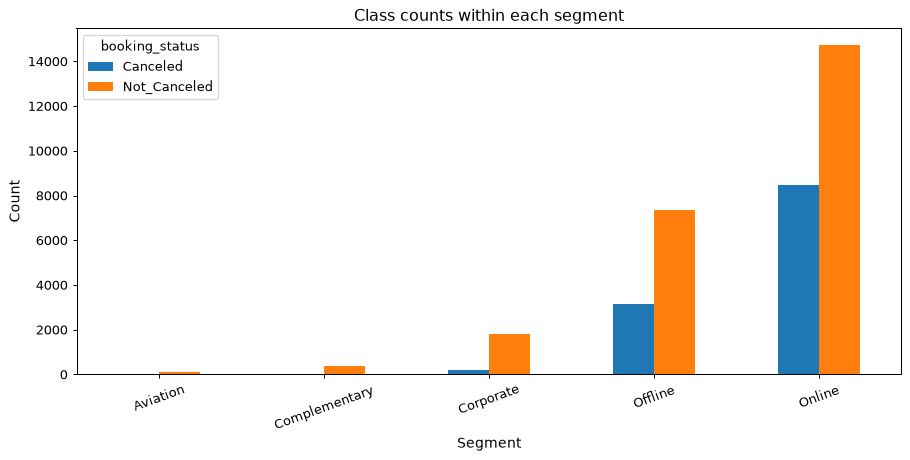

In [6]:
display(pd.crosstab(data.market_segment_type, data.booking_status))
display(data.groupby('booking_status')[['lead_time', 'avg_price_per_room']].mean())
fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
pd.crosstab(data.market_segment_type, data.booking_status).plot.bar(ax=ax, rot=20)
ax.set(xlabel='Segment', ylabel='Count', title='Class counts within each segment')
plt.show()

**Observation:** Compare class counts and group means.

Online bookings form the largest segment in both classes. Mean lead time is 139.215 for cancelled bookings and 58.927 for non-cancelled bookings.

**Explanation:** What information does grouping preserve that one overall mean hides?

Grouping exposes differences between subsets and shows where the observations are concentrated. An overall mean combines these patterns into one number.

## 5. Inspect feature distributions

Plot histograms for all numeric columns.

**Prediction:** Which columns might have many small values and a few large values?

Counts of uncommon events can concentrate near zero, while quantities such as lead time can have a longer upper tail.

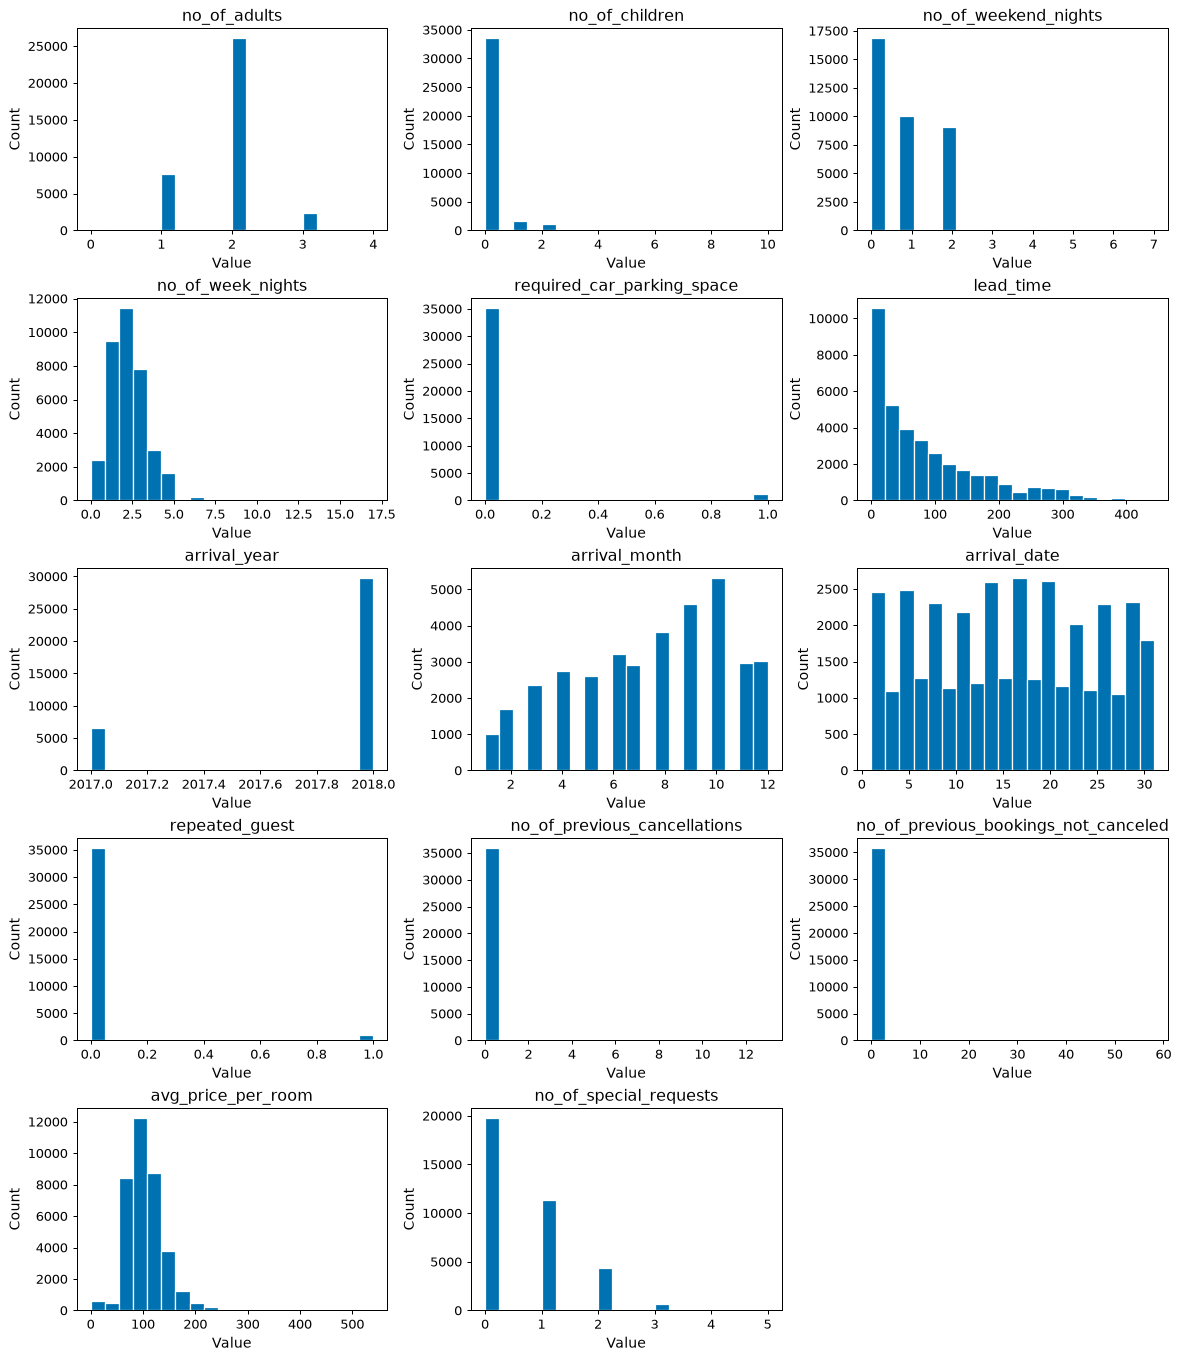

In [7]:
histogram_grid(data)

**Observation:** Identify a skewed distribution and a discrete count distribution.

Lead time has a long upper tail, while the children count is concentrated at zero with a few larger counts. The binary parking indicator occupies only two values.

**Explanation:** How could scale and skew affect a distance-based model?

Features with large numerical ranges can dominate distances. Skew and outlying values can also affect how typical neighbourhoods are represented.

## 6. Compare class proportions and spread

Plot booking-status counts and lead-time distributions by status.

**Prediction:** Can different group means coexist with overlapping distributions?

Yes. Group centres can differ while many individual observations occupy the same range.

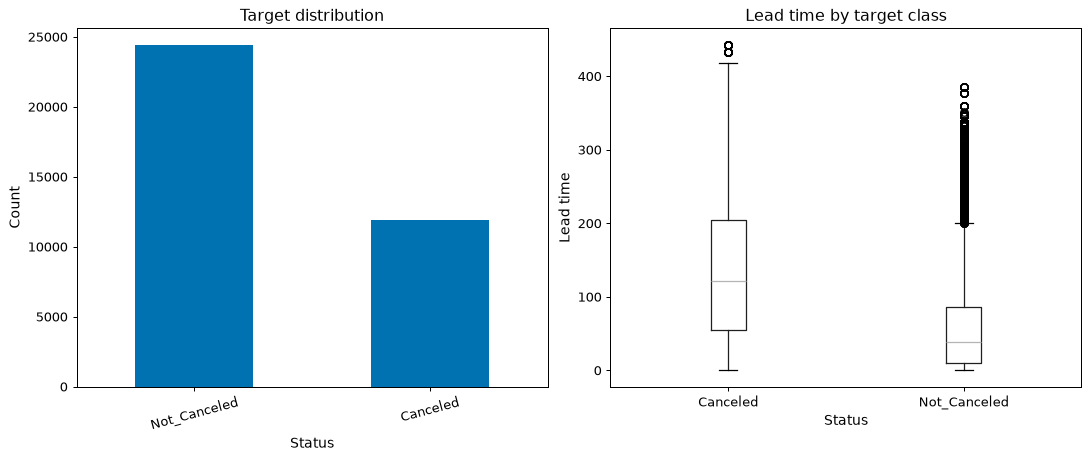

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
data.booking_status.value_counts().plot.bar(ax=axes[0], rot=15, color='#0072B2')
axes[0].set(xlabel='Status', ylabel='Count', title='Target distribution')
data.boxplot(column='lead_time', by='booking_status', ax=axes[1], grid=False)
axes[1].set(xlabel='Status', ylabel='Lead time', title='Lead time by target class')
fig.suptitle('')
plt.show()

**Observation:** Compare medians, spread and overlap.

The non-cancelled class is larger. Cancelled bookings have a higher median lead time and a wider central range, but the two boxplots overlap substantially.

**Explanation:** Why does a difference between averages not imply perfect classification?

A classifier predicts individual observations, not group averages. Overlapping feature values leave ambiguity even when group summaries differ.